讀取資料

In [1]:
import sqlite3
import pandas as pd

conn = sqlite3.connect("../database/quant.db")
df = pd.read_sql("SELECT * FROM prices", conn)
df["date"] = pd.to_datetime(df["date"])
df.head()

,date,stock_id,open,high,low,close,volume
0,2026-08-01,2330,719.470757,735.878418,716.246460,725.196527,40998652
1,2026-08-02,2330,706.714099,716.130321,695.630342,710.933182,40496407
2,2026-08-03,2330,731.874173,738.378501,727.321056,728.205131,24620257
3,2026-08-04,2330,721.058727,736.207962,713.057179,722.611045,45756420
4,2026-08-05,2330,723.047046,725.775707,717.072071,718.949062,26892335


基本統計

In [2]:
df.describe()

,date,open,high,low,close,volume
count,90,90.000000,90.000000,90.000000,90.000000,9.000000e+01
mean,2026-08-15 12:00:00,407.198846,412.812292,402.894607,407.513144,2.752934e+07
min,2026-08-01 00:00:00,132.308888,133.553457,131.647698,132.969273,5.719580e+06
25%,2026-08-08 00:00:00,140.301420,142.757010,139.265102,140.697473,1.596564e+07
50%,2026-08-15 12:00:00,327.878359,332.523566,324.603968,329.205557,2.683157e+07
75%,2026-08-23 00:00:00,735.011597,745.018458,727.515618,734.793098,4.044419e+07
max,2026-08-30 00:00:00,796.476670,809.629542,790.125124,798.216810,4.987781e+07
std,NaN,259.607109,263.312273,257.003669,259.751795,1.363845e+07


groupby() -> 按照某個欄位進行分類(這裡是stock_id)  
["close"] ->  只對此欄位做計算  
agg() -> 進行運算(多個一次執行)
mean: 平均值  
std: 標準差，代表波動率，用來衡量「風險」的核心指標  
用來快速判斷一支股票  

In [3]:
df.groupby("stock_id")["close"].agg(["mean", "std", "min", "max"])

,mean,std,min,max
stock_id,,,,
2317,328.540254,10.061975,312.668669,349.042415
2330,755.398093,22.386200,710.933182,798.216810
2454,138.601086,2.747393,132.969273,144.257437


把股票基本資料接進來

In [4]:
stocks_df = pd.read_sql("SELECT * FROM stocks", conn)
merged = df.merge(stocks_df, on = "stock_id")
merged.head()

,date,stock_id,open,high,low,close,volume,name,industry
0,2026-08-01,2330,719.470757,735.878418,716.246460,725.196527,40998652,台積電,半導體
1,2026-08-02,2330,706.714099,716.130321,695.630342,710.933182,40496407,台積電,半導體
2,2026-08-03,2330,731.874173,738.378501,727.321056,728.205131,24620257,台積電,半導體
3,2026-08-04,2330,721.058727,736.207962,713.057179,722.611045,45756420,台積電,半導體
4,2026-08-05,2330,723.047046,725.775707,717.072071,718.949062,26892335,台積電,半導體


按產業分組看平均股價

In [5]:
merged.groupby("industry")["close"].mean()

industry
半導體      446.999589
電子零組件    328.540254
Name: close, dtype: float64

計算日報酬率(漲幅): pct_change()

In [7]:
df = df.sort_values(["stock_id", "date"])
df["daily_return"] = df.groupby("stock_id")["close"].pct_change()
df[["date", "stock_id", "close", "daily_return"]].head(10)

,date,stock_id,close,daily_return
30,2026-08-01,2317,337.097579,NaN
31,2026-08-02,2317,338.306012,0.003585
32,2026-08-03,2317,334.639497,-0.010838
33,2026-08-04,2317,327.222459,-0.022164
34,2026-08-05,2317,319.679134,-0.023053
35,2026-08-06,2317,326.274300,0.020631
36,2026-08-07,2317,323.115309,-0.009682
37,2026-08-08,2317,332.480045,0.028983
38,2026-08-09,2317,330.598202,-0.005660
39,2026-08-10,2317,331.448074,0.002571


計算移動平均

In [9]:
df["ma_5"] = df.groupby("stock_id")["close"].transform(lambda x: x.rolling(5).mean())
df[["date", "stock_id", "close", "ma_5"]].dropna().head(10)

,date,stock_id,close,ma_5
34,2026-08-05,2317,319.679134,331.388936
35,2026-08-06,2317,326.274300,329.224280
36,2026-08-07,2317,323.115309,326.186140
37,2026-08-08,2317,332.480045,325.754250
38,2026-08-09,2317,330.598202,326.429398
39,2026-08-10,2317,331.448074,328.783186
40,2026-08-11,2317,323.357495,328.199825
41,2026-08-12,2317,317.343672,327.045498
42,2026-08-13,2317,317.190736,323.987636
43,2026-08-14,2317,316.068150,321.081625


把日資料轉成週資料

In [10]:
weekly = (
    df.set_index("date")
    .groupby("stock_id")["close"]
    .resample("W")
    .last()
)
weekly.head(10)

stock_id  date      
2317      2026-08-02    338.306012
          2026-08-09    330.598202
          2026-08-16    313.331284
          2026-08-23    340.849631
          2026-08-30    330.807378
2330      2026-08-02    710.933182
          2026-08-09    751.808051
          2026-08-16    735.971687
          2026-08-23    777.479087
          2026-08-30    774.181107
Name: close, dtype: float64

畫圖

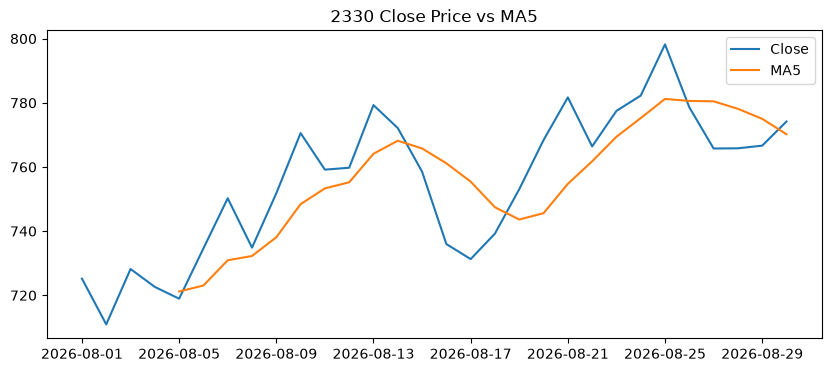

In [11]:
import matplotlib.pyplot as plt

sample = df[df["stock_id"] == "2330"]
plt.figure(figsize=(10, 4))
plt.plot(sample["date"], sample["close"], label="Close")
plt.plot(sample["date"], sample["ma_5"], label="MA5")
plt.legend()
plt.title("2330 Close Price vs MA5")
plt.show()